# 1 — Dataset e preprocessing

Dati per addestrare la generazione di MRI cerebrali T1 *skull-stripped* di soggetti sani (HC).

**Dataset**: 1007 volumi T1 da 6 collezioni pubbliche (ADNI, NIFD, OASIS1, OASIS2, OASIS3, PPMI).

**Split**: 805 training / 100 validation / 102 test.

**Preprocessing**: riorientamento, resize a `256^3`, normalizzazione intensita' `[0,1]` via `get_encoding_transforms()` (lo stesso usato per produrre i latenti dell'LDM).

In [1]:
import os, sys, json, glob
ROOT=os.path.abspath("..")
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline

def show_ortho(vol, title=None, ax_row=None, cmap="gray"):
    """Mostra le 3 viste ortogonali (centrali) di un volume 3D."""
    if hasattr(vol, "numpy"):
        vol=vol.numpy()
    vol=np.asarray(vol).squeeze()
    x, y, z=[s//2 for s in vol.shape]
    views=[(np.rot90(vol[x, :, :]), "Sagittale"),
             (np.rot90(vol[:, y, :]), "Coronale"),
             (np.rot90(vol[:, :, z]), "Assiale")]
    axes = ax_row if ax_row is not None else plt.subplots(1, 3, figsize=(12, 4))[1]
    for a, (img, name) in zip(axes, views):
        a.imshow(img, cmap=cmap); a.set_title(name); a.axis("off")
    if title and ax_row is None:
        plt.suptitle(title); plt.tight_layout()
    return axes


## Composizione dello split

In [2]:
with open("data/splits/dataset.json") as f:
    splits=json.load(f)
for k in ["training", "validation", "test"]:
    print(f"{k:>11}: {len(splits[k])} volumi")
print("totale     :", sum(len(splits[k]) for k in splits))

from collections import Counter
def dataset_of(path):
    for d in ["adni","nifd","oasis1","oasis2","oasis3","ppmi"]:
        if f"hc_{d}_" in path: return d
    return "altro"
all_items=splits["training"] + splits["validation"] + splits["test"]
counts=Counter(dataset_of(it["image"]) for it in all_items)
print("\nVolumi per dataset:")
for d, c in sorted(counts.items()): print(f"  {d:>7}: {c}")

   training: 805 volumi
 validation: 100 volumi
       test: 102 volumi
totale     : 1007

Volumi per dataset:
     adni: 319
     nifd: 118
   oasis1: 131
   oasis2: 72
   oasis3: 168
     ppmi: 199


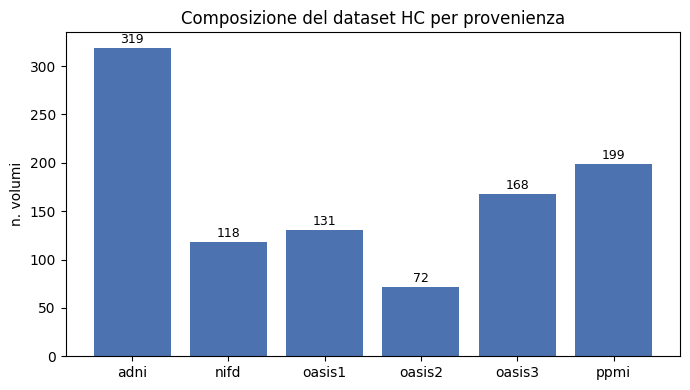

In [3]:
fig, ax=plt.subplots(figsize=(7, 4))
ds=sorted(counts.items())
ax.bar([d for d,_ in ds], [c for _,c in ds], color="#4c72b0")
ax.set_ylabel("n. volumi"); ax.set_title("Composizione del dataset HC per provenienza")
for i,(d,c) in enumerate(ds): ax.text(i, c+5, str(c), ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## Esempi di volumi reali dopo preprocessing
Applichiamo `get_encoding_transforms()`: risultato `256^3`, intensita' `[0,1]`.

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


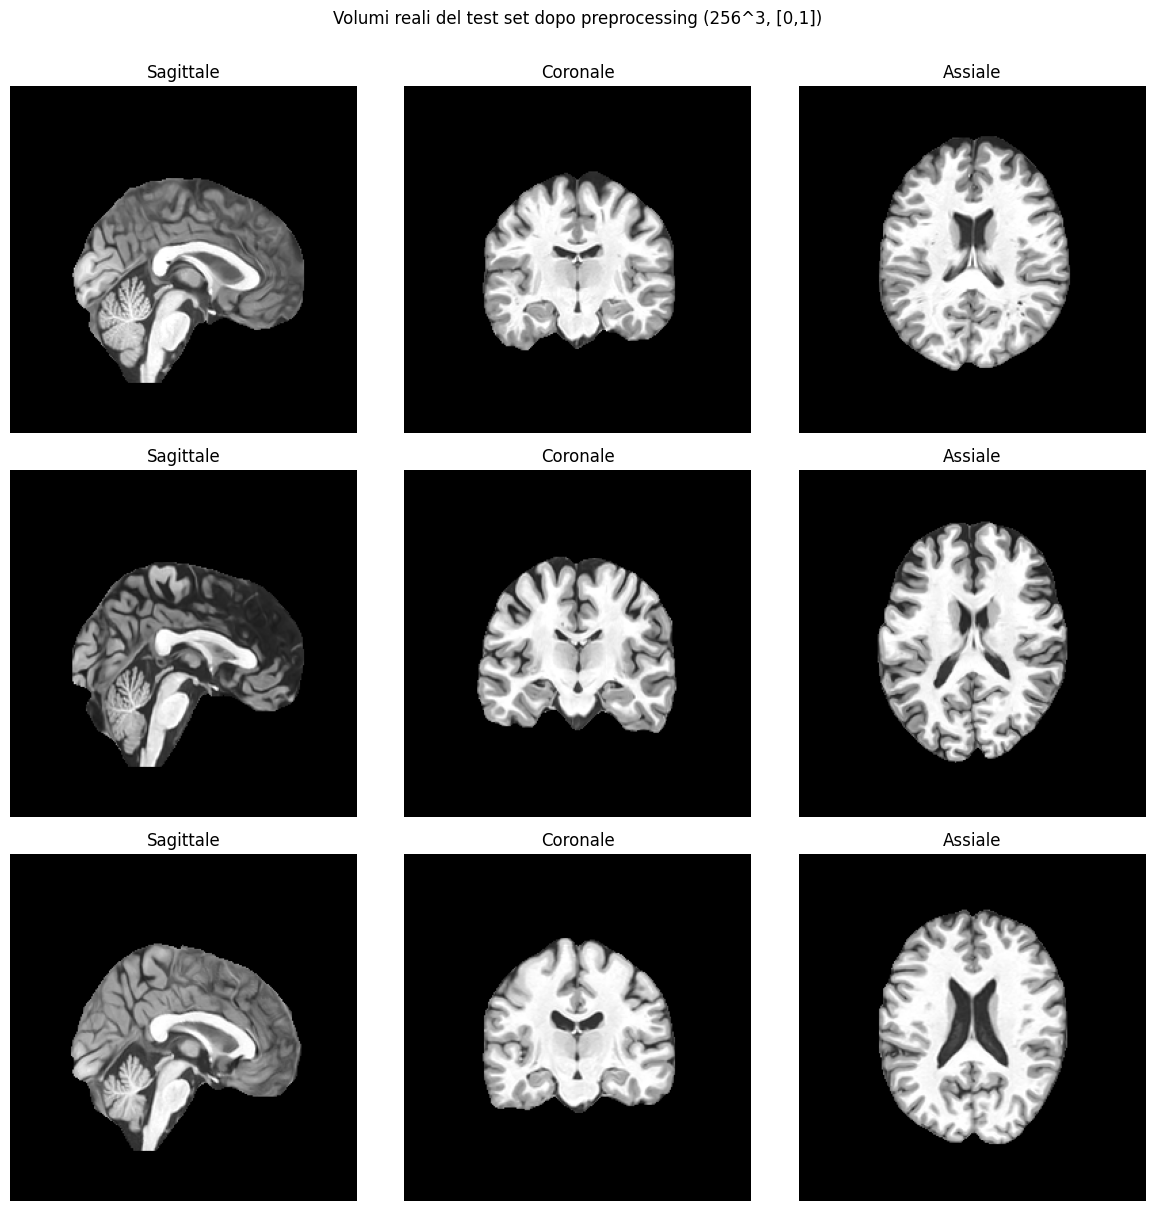

In [4]:
from src.data.transforms import get_encoding_transforms
tf=get_encoding_transforms()

n_show=3
fig, axes=plt.subplots(n_show, 3, figsize=(12, 4*n_show))
for r in range(n_show):
    item=splits["test"][r]
    out=tf({"image": item["image"]})
    img=out["image"]
    if hasattr(img, "as_tensor"): img=img.as_tensor()
    img=img.squeeze(0).numpy()
    show_ortho(img, ax_row=axes[r])
plt.suptitle("Volumi reali del test set dopo preprocessing (256^3, [0,1])", y=1.005)
plt.tight_layout(); plt.show()

In [5]:
item=splits["test"][0]
out=tf({"image": item["image"]})
img=out["image"]
if hasattr(img, "as_tensor"): img=img.as_tensor()
print("shape :", tuple(img.shape))
print("range : [%.3f, %.3f]" % (float(img.min()), float(img.max())))

shape : (1, 256, 256, 256)
range : [0.000, 1.000]


**Osservazione.** Volumi di collezioni diverse (shape/intensita' eterogenee) vengono portati nello stesso spazio canonico `256^3 / [0,1]`. Questo allineamento rende confrontabili reali e sintetiche in fase di valutazione.